5. 프로젝트: 더 멋진 번역기 만들기

In [1]:
import torch
import numpy
import matplotlib

print(torch.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.7.1+cu118
2.2.6
3.10.3


In [8]:
import os

data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir + "/korean-english-park.train.ko"
eng_path = data_dir + "/korean-english-park.train.en"

print(kor_path)
print(eng_path)

/home/jovyan/work/transformer/data/korean-english-park.train.ko
/home/jovyan/work/transformer/data/korean-english-park.train.en


In [2]:
!mkdir ~/work/transformer/data

mkdir: cannot create directory ‘/home/jovyan/work/transformer/data’: No such file or directory


In [5]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P ~/work/transformer/data
!gzip -df ~/work/transformer/data/korean-english-park.train.tar.gz
!tar -xvf ~/work/transformer/data/korean-english-park.train.tar

--2026-05-13 06:20:36--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-05-13 06:20:36--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘/home/jovyan/work/transformer/data/korean-e

In [10]:
!ls -la ~/work/transformer/data/

total 42160
drwxr-sr-x 2 jovyan users     4096 May 13 06:21 .
drwxr-sr-x 3 jovyan users     4096 May 13 06:16 ..
-rw-r--r-- 1 jovyan users 25722880 May 13 06:18 korean-english-park.train.tar
-rw-r--r-- 1 jovyan users  8718893 May 13 06:21 korean-english-park.train.tar.gz
-rw-r--r-- 1 jovyan users  8718893 May 13 06:20 korean-english-park.train.tar.gz.1


In [11]:
import os
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
print(os.listdir(data_dir))

['korean-english-park.train.tar', 'korean-english-park.train.tar.gz.1', 'korean-english-park.train.tar.gz']


In [12]:
!tar -xzf ~/work/transformer/data/korean-english-park.train.tar.gz -C ~/work/transformer/data/
!ls -la ~/work/transformer/data/

total 67276
drwxr-sr-x 2 jovyan users     4096 May 13 06:25 .
drwxr-sr-x 3 jovyan users     4096 May 13 06:16 ..
-rw-r--r-- 1 jovyan users 11982221 Jul 12  2014 korean-english-park.train.en
-rw-r--r-- 1 jovyan users 13730884 Jul 12  2014 korean-english-park.train.ko
-rw-r--r-- 1 jovyan users 25722880 May 13 06:18 korean-english-park.train.tar
-rw-r--r-- 1 jovyan users  8718893 May 13 06:21 korean-english-park.train.tar.gz
-rw-r--r-- 1 jovyan users  8718893 May 13 06:20 korean-english-park.train.tar.gz.1


In [9]:
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir+"/korean-english-park.train.ko"
eng_path = data_dir+"/korean-english-park.train.en"

# 데이터 정제 및 토큰화
def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)

    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))

    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/work/transformer/data/korean-english-park.train.ko'

In [13]:
!find ~/work/transformer/data/ -name "*.ko"
!find ~/work/transformer/data/ -name "*.en"

/home/jovyan/work/transformer/data/korean-english-park.train.ko
/home/jovyan/work/transformer/data/korean-english-park.train.en


In [14]:
def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)
    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))
    return cleaned_corpus

In [15]:
with open(kor_path, "r", encoding="utf-8") as f: 
    kor = f.read().splitlines()

In [16]:
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = data_dir+"/korean-english-park.train.ko"
eng_path = data_dir+"/korean-english-park.train.en"

# 데이터 정제 및 토큰화
def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f: kor = f.read().splitlines()
    with open(eng_path, "r") as f: eng = f.read().splitlines()
    assert len(kor) == len(eng)

    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))

    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)

In [18]:
def preprocess_sentence(sentence):

  sentence = sentence.lower()
  sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  return sentence

In [20]:
import re

In [56]:
# Sentencepiece를 활용하여 학습한 tokenizer를 생성합니다.
def generate_tokenizer(corpus,
                        vocab_size,
                        lang="ko",
                        pad_id=0,
                        bos_id=1,
                        eos_id=2,
                        unk_id=3):
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, 'w') as f:
      for row in corpus: f.write(str(row) + '\n')

    import sentencepiece as spm
    spm.SentencePieceTrainer.Train(
      '--input=./%s --model_prefix=%s --vocab_size=%d'\
      % (file, model, vocab_size) + \
      '--pad_id=%d --bos_id=%d --eos_id=%d --unk_id=%d'\
      % (pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load('%s.model' % model)

    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

eng_corpus = []
kor_corpus = []

for pair in cleaned_corpus:
    k, e = pair.split("\t")

    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
en_tokenizer.set_encode_extra_options("bos:eos")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 

True

In [26]:
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=././ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000--pad_id==0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ././ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id:

In [25]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.2 MB/s eta 0:00:00a 0:00:01


In [28]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm  # 진행 과정 보기

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰의 길이가 50 이하인 문장만 남깁니다.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리를 완료하여 학습용 데이터를 완성합니다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(enc_train.shape, dec_train.shape)

  0%|          | 0/78968 [00:00<?, ?it/s]

torch.Size([73292, 50]) torch.Size([73292, 50])


In [29]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):

        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

In [31]:
import torch.nn as nn

In [55]:
# ─────────── ① Optimizer 먼저 ───────────
optimizer = torch.optim.Adam(
    transformer.parameters(),    # ← Cell 30에서 만든 transformer!
    lr=1e-4,                     # 초기값 (scheduler가 덮어씀)
    betas=(0.9, 0.98),
    eps=1e-9
)

# ─────────── ② Scheduler 나중에 ───────────
scheduler = LearningRateScheduler(optimizer, d_model=512)

# ─────────── ③ 손실 함수 ───────────
criterion = nn.CrossEntropyLoss(ignore_index=0)  # padding(0) 무시

# 확인
n_params = sum(p.numel() for p in transformer.parameters())
print(f"모델 파라미터 수: {n_params:,}")
print(f"Optimizer: {type(optimizer).__name__}")
print(f"Scheduler: {type(scheduler).__name__}")

모델 파라미터 수: 35,212,832
Optimizer: Adam
Scheduler: LearningRateScheduler


In [32]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]
        QK = torch.matmul(Q, K.transpose(-2, -1))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk = scaled_qk.masked_fill(mask == 0, float('-1e9'))

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

In [33]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)

        return out

In [34]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

In [35]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

In [36]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

In [37]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []

        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, causality_mask, padding_mask
            )

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

In [38]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):

        super(Transformer, self).__init__()

        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.shape[1]

        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))

        pos_enc = self.pos_encoding[:seq_len, :].unsqueeze(0).to(x.device)
        out += pos_enc

        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns


In [39]:
def generate_padding_mask(seq):
    """ 패딩된 부분(0)을 1로 변환하여 마스크 생성 """
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(src_len, tgt_len):
    """ 미래 정보를 참조하지 않도록 Causal Mask 생성 """
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    """ Encoder-Decoder에서 사용할 마스크 생성 """
    enc_mask = generate_padding_mask(src)
    dec_mask = generate_padding_mask(tgt)

    dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    dec_mask = torch.max(dec_mask, dec_causality_mask.to(dec_mask.device))

    dec_enc_causality_mask = generate_causality_mask(tgt.shape[1], src.shape[1])
    dec_enc_mask = torch.max(enc_mask, dec_enc_causality_mask.to(enc_mask.device))

    return enc_mask, dec_enc_mask, dec_mask

In [41]:
import numpy as np

In [48]:
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
)

In [49]:
import math

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]

In [57]:
learning_rate = LearningRateScheduler(optimizer, d_model=512)

optimizer = torch.optim.Adam(optimizer.param_groups,
                             lr=learning_rate.get_lr()[0],
                             betas=(0.9, 0.98),
                             eps=1e-9)

In [58]:
loss_object = torch.nn.CrossEntropyLoss(reduction='none')

def loss_function(real, pred):
    mask = (real != 0)
    loss_ = loss_object(pred, real)

    # Masking 되지 않은 입력의 개수로 Scaling하는 과정
    mask = mask.float()
    loss_ *= mask

    return loss_.sum() / mask.sum()

In [59]:
# Train Step 함수 정의
def train_step(src, tgt, model, optimizer):
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

    # 계산된 loss에 대해 역전파(Backpropagation)를 적용해 학습을 진행합니다.
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions[:, :-1])

    loss.backward()

    # 최종적으로 optimizer.step()이 사용됩니다.
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns


In [60]:
# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    def draw(data, ax, x="auto", y="auto"):
        import seaborn
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer+1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer+1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

In [61]:
# 번역 생성 함수

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    sentence = preprocess_sentence(sentence)

    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)

    _input = torch.tensor(tokens).unsqueeze(0)

    ids = []
    output = torch.tensor([tgt_tokenizer.bos_id()]).unsqueeze(0)
    for i in range(dec_train.shape[-1]):
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(_input, output)

        predictions, enc_attns, dec_attns, dec_enc_attns = \
        model(_input, output, enc_padding_mask, combined_mask, dec_padding_mask)

        predicted_id = torch.argmax(torch.softmax(predictions, dim=-1)[0, -1]).item()

        if tgt_tokenizer.eos_id() == predicted_id:
            result = tgt_tokenizer.decode_ids(ids)
            return pieces, result, enc_attns, dec_attns, dec_enc_attns

        ids.append(predicted_id)
        output = torch.cat([output, torch.tensor([[predicted_id]])], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)

    return pieces, result, enc_attns, dec_attns, dec_enc_attns

In [62]:
# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = \
    evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)

## 프로젝트: Transformer로 한영 번역기 만들기

#  프로젝트: Transformer로 한영 번역기 만들기

> **목표**: "Attention is All You Need" 논문에 등장하는 Transformer 아키텍처를
>
> 
> 처음부터 직접 구현하여 한국어 → 영어 번역기를 만든다.
>
> **데이터**: korean-parallel-corpora (한국어-영어 뉴스 병렬 코퍼스)

---

##  프로젝트 평가 기준 (루브릭)

| 학습 목표 | 평가 기준 |
|---|---|
| 텍스트 데이터 전처리 | 데이터 정제, SentencePiece 토큰화 |
| Transformer 정상 구동 | 학습과 추론 정상 동작 |
| 의미 있는 번역 결과 | 그럴듯한 영어 번역 + Attention Map |

In [63]:
# ───── 기본 라이브러리 ─────
import os
import re
import math
import random
from collections import Counter

# ───── 수치 연산 & 시각화 ─────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ───── PyTorch ─────
import torch
import torch.nn as nn
import torch.nn.functional as F

# ───── 토크나이저 & 진행률 표시 ─────
import sentencepiece as spm
from tqdm.notebook import tqdm

# ───── 재현성을 위한 시드 고정 ─────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ───── 디바이스 설정 ─────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch: {torch.__version__}")
print(f"NumPy:   {np.__version__}")
print(f"Device:  {device}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")

PyTorch: 2.7.1+cu118
NumPy:   2.2.6
Device:  cuda
GPU:     Tesla T4


## 데이터 준비

In [64]:
# 데이터 저장 디렉토리 생성 (-p: 이미 있어도 에러 안 남, 부모 폴더도 자동 생성)
!mkdir -p ~/work/transformer/data

# 데이터 다운로드 (-q: 진행 로그 안 보이게, -O: 저장 경로 명시)
!wget -q https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz \
    -O ~/work/transformer/data/korean-english-park.train.tar.gz

# 압축 해제 (tar -xzf로 한 번에 처리, z=gzip 자동 해제)
!tar -xzf ~/work/transformer/data/korean-english-park.train.tar.gz -C ~/work/transformer/data/

# 결과 확인
!ls -la ~/work/transformer/data/

total 67276
drwxr-sr-x 2 jovyan users     4096 May 13 07:00 .
drwxr-sr-x 3 jovyan users     4096 May 13 06:16 ..
-rw-r--r-- 1 jovyan users 11982221 Jul 12  2014 korean-english-park.train.en
-rw-r--r-- 1 jovyan users 13730884 Jul 12  2014 korean-english-park.train.ko
-rw-r--r-- 1 jovyan users 25722880 May 13 06:18 korean-english-park.train.tar
-rw-r--r-- 1 jovyan users  8718893 May 13 07:00 korean-english-park.train.tar.gz
-rw-r--r-- 1 jovyan users  8718893 May 13 06:20 korean-english-park.train.tar.gz.1


### 코드 — 데이터 경로 변수 설정

In [65]:
# 데이터 경로 설정 (os.path.join으로 OS 독립적인 경로 생성)
data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')
kor_path = os.path.join(data_dir, "korean-english-park.train.ko")
eng_path = os.path.join(data_dir, "korean-english-park.train.en")

print(f"한국어: {kor_path}")
print(f"영어:   {eng_path}")

한국어: /home/jovyan/work/transformer/data/korean-english-park.train.ko
영어:   /home/jovyan/work/transformer/data/korean-english-park.train.en


## 데이터 정제 (Cleaning)

원본 데이터에서 **중복 문장 쌍을 제거**해요. 동일한 한영 쌍이 여러 번 등장하면
학습 데이터의 다양성이 떨어지고, 특정 패턴에 과적합될 수 있다.

**구현 트릭**: 한국어와 영어를 `\t`(탭)으로 묶어 하나의 문자열로 만든 뒤
`set()`에 넣어 중복 제거 → 다시 분리하는 방식. 한 쌍을 묶어서 다루는 게 핵심!!!

In [66]:
def clean_corpus(kor_path, eng_path):
    """
    한국어-영어 병렬 코퍼스를 읽어 중복을 제거한다.
    한국어와 영어를 탭으로 묶어 하나의 단위로 다루므로
    "같은 한영 쌍"만 중복으로 처리되고, 한쪽만 같은 경우는 보존된다.
    """
    # encoding="utf-8" 명시: 한국어 데이터는 인코딩 문제로 깨질 수 있어 안전장치
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()
    
    # 한/영 줄 수가 다르면 짝이 안 맞으므로 학습 불가
    assert len(kor) == len(eng), f"줄 수 불일치: kor={len(kor)}, eng={len(eng)}"
    
    # 탭으로 묶어 한 쌍을 한 문자열로 → set으로 중복 제거
    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))
    
    print(f"원본 데이터: {len(kor):,}개")
    print(f"중복 제거 후: {len(cleaned_corpus):,}개")
    print(f"제거된 중복: {len(kor) - len(cleaned_corpus):,}개")
    
    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)

원본 데이터: 94,123개
중복 제거 후: 78,968개
제거된 중복: 15,155개


## 문장 단위 전처리

각 문장을 모델이 학습하기 좋게 정제해보자

| 단계 | 하는 일 | 예시 |
|---|---|---|
| ① | 소문자화 | "Hello" → "hello" |
| ② | 특수문자 제거 | "안녕@#$" → "안녕 " |
| ③ | 구두점 분리 | "안녕,세상" → "안녕 , 세상" |
| ④ | 연속 공백 → 하나로 | "안녕   세상" → "안녕 세상" |

특히 **③번이 중요**. 구두점을 단어로부터 분리해야 토크나이저가
"안녕,"을 한 단어로 보지 않고 "안녕"과 ","로 따로 인식해서 \
깔끔쓰.

In [67]:
def preprocess_sentence(sentence):
    """문장 단위 정제 함수. 토크나이저에 넣기 좋은 형태로 다듬는다."""
    sentence = sentence.lower()                                    # ① 소문자화
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)        # ② 한/영/구두점 외 제거
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)              # ③ 구두점 양옆에 공백
    sentence = re.sub(r'[" "]+', " ", sentence)                    # ④ 연속 공백 → 단일 공백
    sentence = sentence.strip()                                    # ⑤ 양 끝 공백 제거
    return sentence

# 동작 확인 — 의도한 대로 정제되는지 눈으로 검사
test = "Hello, World!! 안녕하세요...   반갑습니다."
print(f"전: {test}")
print(f"후: {preprocess_sentence(test)}")

전: Hello, World!! 안녕하세요...   반갑습니다.
후: hello , world ! ! 안녕하세요 . . . 반갑습니다 .


구두점이 모두 떨어져 나와있고 공백이 하나로 정리된걸보니 일단 합격!

In [68]:
# 모든 문장에 전처리 적용
eng_corpus = []
kor_corpus = []

for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

# 샘플 5개 확인 — 한영 쌍이 잘 매칭되는지 눈으로 검사
print(f"전처리 완료: {len(kor_corpus):,}쌍\n")
for i in range(5):
    print(f"[{i}] 한: {kor_corpus[i]}")
    print(f"    영: {eng_corpus[i]}\n")

전처리 완료: 78,968쌍

[0] 한: 국제 공항 근방에서 철저하게 프레틸린을 지지하는 난민 캠프 출신의 약 명의 젊은이들이 지난 화요일 경찰에 돌을 던졌다고 , 프랑스의 afp 통신사의 기자가 보도했다 .
    영: about youths from a predominantly pro fretilin refugee camp near the international airport threw rocks at police on tuesday , according to a reporter for the french news agency afp .

[1] 한: 그 세력이 약화된 미타그 는 시속 km의 강풍을 동반하며 일 오전 필리핀 북동부 바타네스섬 부근을 통과했다 .
    영: a weakened mitag was moving northeast close to northern batanes islands at kph mph , with kph mph winds near the center and gusts of up to kph mph .

[2] 한: 결국 그의 친부는 그를 고아원에 맡겼다 .
    영: his father has said he believed he could not care for him alone , and that placing him in an orphanage was the best way to ensure david s survival .

[3] 한: 이동관 청와대 대변인은 정부는 북한의 미사일 발사가 훈련 차원에서 이뤄진 것으로 추정한다 고 밝혔다 .
    영: the government regards north korea s missile firing as merely a part of its ordinary military training , presidential spokesman lee dong kwan told yonhap .

[4] 한: 미 국립질병관리예방센터 centers for disease control 

---

#  SentencePiece 토크나이저

##  SentencePiece

단순히 공백으로 단어를 자르면 **vocab이 너무 커지고**, **모르는 단어(OOV)** 가 자주 나옴.
SentencePiece는 **Subword Tokenization** 으로 이 문제를 해결가능하다:

- "running" → ["run", "ning"]
- "낮잠" → ["낮", "잠"]
- 모르는 단어도 알려진 subword들로 분해해 처리 가능
- vocab 크기를 우리가 직접 조절 가능 (보통 8K~32K)

## 3.2 특수 토큰

| ID | 토큰 | 역할 |
|---|---|---|
| 0 | `<pad>` | 길이 맞추기 위한 패딩 |
| 1 | `<bos>` | Begin Of Sequence (디코더 시작 신호) |
| 2 | `<eos>` | End Of Sequence (생성 종료 신호) |
| 3 | `<unk>` | 사전에 없는 모르는 토큰 |

In [70]:
def generate_tokenizer(corpus, vocab_size, lang="ko",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    """
    SentencePiece BPE 토크나이저를 학습시키고 반환한다.
    Args:
        corpus: 전처리된 문장 리스트
        vocab_size: 만들 vocab 크기 (보통 8K~32K)
        lang: "ko" or "en" — 파일명에 사용
    """
    # corpus를 임시 파일로 저장 (SentencePiece가 파일에서 학습)
    file = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    
    with open(file, 'w', encoding='utf-8') as f:
        for row in corpus:
            f.write(str(row) + '\n')
    
    # SentencePiece 학습 — 옵션 사이 공백 잘 챙겨야 함!
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )
    
    # 학습된 모델 로드
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')
    return tokenizer

# vocab 크기 설정 — 한국어와 영어 동일하게 20000
SRC_VOCAB_SIZE = 20000
TGT_VOCAB_SIZE = 20000

# 한국어/영어 토크나이저 각각 학습 (1~2분 소요)
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

# 영어 토크나이저는 항상 <bos>...<eos>로 감싸도록 설정
# 디코더 입력으로 들어갈 때 시작/종료 토큰이 필요하기 때문
en_tokenizer.set_encode_extra_options("bos:eos")
print(f"한국어 vocab: {ko_tokenizer.get_piece_size():,}")
print(f"영어 vocab:   {en_tokenizer.get_piece_size():,}")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
 

한국어 vocab: 20,000
영어 vocab:   20,000


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./en_corpus.txt --model_prefix=en_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./en_corpus.txt
  input_format: 
  model_prefix: en_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
 

In [72]:
# 토크나이저 동작 확인
sample_ko = "영어 번역기는 파파고!."
sample_en = "The English translator is Papago."

print("=== 한국어 ===")
print(f"문장:    {sample_ko}")
print(f"조각:    {ko_tokenizer.encode_as_pieces(sample_ko)}")
print(f"ID:      {ko_tokenizer.encode_as_ids(sample_ko)}")
print()
print("=== 영어 (bos/eos 자동 추가됨) ===")
print(f"문장:    {sample_en}")
print(f"조각:    {en_tokenizer.encode_as_pieces(sample_en)}")
print(f"ID:      {en_tokenizer.encode_as_ids(sample_en)}")

=== 한국어 ===
문장:    영어 번역기는 파파고!.
조각:    ['▁영어', '▁번역', '기', '는', '▁파', '파', '고', '!', '.']
ID:      [1614, 5064, 59, 6, 649, 479, 15, 19930, 19998]

=== 영어 (bos/eos 자동 추가됨) ===
문장:    The English translator is Papago.
조각:    ['<s>', '▁', 'T', 'he', '▁', 'E', 'ng', 'l', 'ish', '▁translator', '▁is', '▁', 'P', 'a', 'pago', '.', '</s>']
ID:      [1, 24, 3, 5168, 24, 3, 1799, 101, 181, 7264, 22, 24, 3, 99, 15726, 19999, 2]


## 토크나이저가 잘 작동하는것 같다 乃

##  토큰화 + 길이 필터링 + 패딩

학습용 데이터셋 완성 단계:

1. 각 문장을 ID 시퀀스로 변환
2. **길이가 50 토큰 이하**인 문장만 사용 (메모리 효율 + 학습 안정성)
3. **Padding** — 짧은 문장을 0으로 채워서 길이를 맞춤 (배치 처리에 필수)

In [74]:
src_corpus = []  # 소스(한국어) 토큰
tgt_corpus = []  # 타겟(영어) 토큰

assert len(kor_corpus) == len(eng_corpus)

# 토큰 길이 50 이하인 문장만 채택
# 너무 긴 문장은 (1) 메모리 부담 (2) 학습 어려움 → 일단 짧은 것부터
MAX_LEN = 50

for idx in tqdm(range(len(kor_corpus)), desc="Tokenizing"):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])
    
    if len(src_tokens) <= MAX_LEN and len(tgt_tokens) <= MAX_LEN:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    """가장 긴 문장을 기준으로 0(패딩)을 채워 텐서로 만든다."""
    return torch.nn.utils.rnn.pad_sequence(
        sequences, batch_first=True, padding_value=padding_value
    )

enc_train = pad_sequences(src_corpus, padding_value=0)  # (N, max_src_len)
dec_train = pad_sequences(tgt_corpus, padding_value=0)  # (N, max_tgt_len)

print(f"\n학습 데이터 크기:")
print(f"  Encoder 입력: {enc_train.shape}")  # (문장 수, 패딩된 최대 길이)
print(f"  Decoder 입력: {dec_train.shape}")

Tokenizing:   0%|          | 0/78968 [00:00<?, ?it/s]


학습 데이터 크기:
  Encoder 입력: torch.Size([72107, 50])
  Decoder 입력: torch.Size([72107, 50])


## Transformer 모델 구현

Positional Encoding (위치 정보)\
↓\
Multi-Head Attention (핵심 메커니즘)\
↓\
Position-wise FFN (개별 가공)\
↓\
Encoder Layer / Decoder Layer (한 층의 구조)\
↓\
Encoder / Decoder (여러 층 쌓기)\
↓\
Transformer (전체 모델)


## Positional Encoding

Transformer는 입력을 한꺼번에 처리하므로 **순서 정보를 잃어버린다**.
그래서 sin/cos 함수로 위치 정보를 \
임베딩에 더해주는게 중요하다.

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

**왜 sin/cos?**
- **주기성**: 같은 위치는 항상 같은 값 → 일관성
- **값 범위 [-1, 1]**: 단어 임베딩 값을 적절하게 통제하여 학습시간을 줄일수있다.

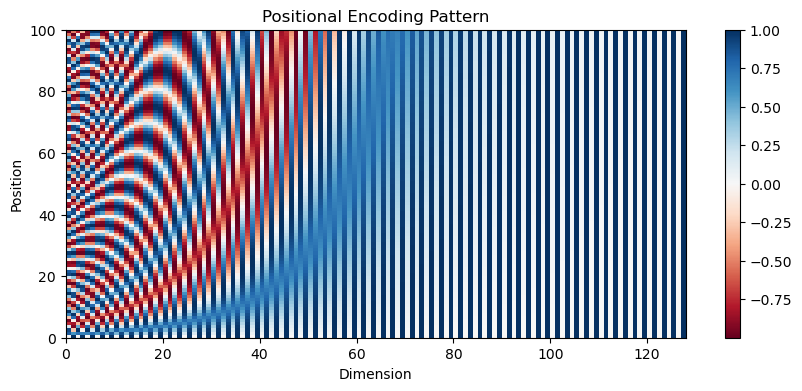

In [75]:
def positional_encoding(pos, d_model):
    """
    sin/cos 기반 위치 인코딩 테이블을 생성한다.
    Args:
        pos: 최대 시퀀스 길이
        d_model: 임베딩 차원 (512)
    Returns:
        (pos, d_model) 형태의 numpy 배열
    """
    def cal_angle(position, i):
        # 분모: 10000^(2i/d_model) → 차원이 클수록 더 긴 주기를 가짐
        return position / np.power(10000, int(i) / d_model)
    
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    
    # 모든 위치 × 모든 차원의 각도 테이블 생성
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    
    # 짝수 인덱스(0, 2, 4...)는 sin
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    # 홀수 인덱스(1, 3, 5...)는 cos
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    
    return sinusoid_table

# 시각화로 패턴 확인 — 정상이라면 부드러운 줄무늬가 보임
pe = positional_encoding(100, 128)
plt.figure(figsize=(10, 4))
plt.pcolormesh(pe, cmap='RdBu')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.colorbar()
plt.title('Positional Encoding Pattern')
plt.show()

## Multi-Head Attention

Transformer의 **심장부**. 우리가 노드에서 배운 4단계를 그대로 구현해보자!!:

1. **Q, K, V 생성** — 입력에 W^Q, W^K, W^V 곱하기
2. **Score 계산** — Q · K^T / √d_k → softmax
3. **Value 가중합** — softmax 결과 × V
4. **Head 합치기** — concat 후 W^O 통과

**구현 트릭**: 노드에서는 W^Q를 8개 따로 만든다고 설명하지만, 실제로는
**하나의 큰 Linear(512×512)** 로 만들고 reshape로 8개 head로 나눈다. 그러면 학습이 빨라짐!! 유튜브는 1.75국룰

In [78]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads  # 각 head의 차원 (512/8 = 64)
        
        # d_model이 num_heads로 나누어 떨어져야 함
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        # 하나의 Linear로 만들고 나중에 reshape로 head 분할 (효율적)
        self.W_q = nn.Linear(d_model, d_model)# Q K V 가중치 행렬
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # 최종 출력을 위한 W^O
        self.linear = nn.Linear(d_model, d_model)
    
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        핵심 attention 연산: softmax(QK^T/√d_k) · V
        """
        d_k = K.shape[-1]
        
        # 1️ Q와 K의 내적 → attention score
        QK = torch.matmul(Q, K.transpose(-2, -1))# Q K^T 내적으로 점수계산
        
        # 2 √d_k로 스케일링 — softmax 포화(saturation) 방지
        # 내적값이 커지면 softmax가 한 쪽에 너무 쏠려서 gradient가 죽음
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
        
        # 3 마스킹: padding이나 미래 토큰은 -∞에 가까운 값으로 → softmax 후 0
        if mask is not None:
            scaled_qk = scaled_qk.masked_fill(mask == 1, -1e9)
        
        # 4 softmax로 확률 분포 만들기
        attentions = F.softmax(scaled_qk, dim=-1)
        
        # 5 Value와 가중합
        out = torch.matmul(attentions, V)
        return out, attentions
    
    def split_heads(self, x):
        """
        (batch, seq_len, d_model) → (batch, num_heads, seq_len, depth)
        한 번에 한 텐서를 head 개수만큼 쪼개서 병렬 연산 가능하게 한다.
        """
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch, heads, seq, depth)
        return x
    
    def combine_heads(self, x):
        """split_heads의 역연산: 다시 합쳐서 (batch, seq_len, d_model)로"""
        bsz, num_heads, seq_len, depth = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()  # contiguous: 메모리 연속성 확보
        x = x.view(bsz, seq_len, self.d_model)
        return x
    
    def forward(self, Q, K, V, mask=None):
        # 1 입력에 W_q, W_k, W_v 곱하기
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)
        
        # 2 Head 개수만큼 쪼개기
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)
        
        # 3 각 head에서 attention 계산 (병렬!)
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )
        
        # 4 Head들 다시 합치고
        out = self.combine_heads(out)
        # 5 최종 Linear (W^O)
        out = self.linear(out)
        
        return out, attention_weights

print("✅ MultiHeadAttention 클래스 정의 완료")

✅ MultiHeadAttention 클래스 정의 완료


## Position-wise Feed Forward Network

각 단어 벡터에 **간단한 2-layer MLP**를 독립적으로 적용

512차원 → Linear → 2048차원 → ReLU → Linear → 512차원

**Why 확장-축소 구조?** 비선형성이 충분히 발휘되려면 충분히 넓은 차원이 필요하다.
중간을 2048로 늘려서 풍부한 변환을 한 뒤, 다시 512로 압축해 원래 차원 유지.

넓은 캔버스에서 여러가지 실험한후 출력할때는 다시 차원을 줄여 효율적인 학습환경을 제공한다

In [80]:
class PoswiseFeedForwardNet(nn.Module):
    """
    Position-wise Feed-Forward Network.
    - "Position-wise": 각 단어마다 같은 네트워크를 독립적으로 적용
    - 512 → 2048 → 512 구조로 표현력 강화
    """
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)  # 차원 확장
        self.fc2 = nn.Linear(d_ff, d_model)  # 차원 축소
        self.relu = nn.ReLU()                # 비선형성 추가
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

print("✅ PoswiseFeedForwardNet 클래스 정의 완료")

✅ PoswiseFeedForwardNet 클래스 정의 완료


##  Encoder Layer

Encoder의 한 층은 **2개의 서브레이어**로 구성:
1. Multi-Head Self-Attention
2. Position-wise FFN

각 서브레이어 뒤에는 항상 **Residual Connection + LayerNorm** 이 따라와요.

**중요**: `out = out + residual`로 작성 (in-place `+=` 쓰면 autograd 문제 발생 가능).

In [81]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        
        # 두 서브레이어 각각에 LayerNorm
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        
        # Dropout: 과적합 방지
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask):
        # ───────── ① Multi-Head Self-Attention ─────────
        # Pre-LN 방식: LayerNorm을 먼저 적용 (학습 안정성이 더 좋음)
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)  # Q=K=V (self-attention)
        out = self.dropout(out)
        out = out + residual  # Residual Connection — `+=` 대신 `+`로!
        
        # ───────── ② Feed Forward Network ─────────
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out = out + residual
        
        return out, enc_attn

print("✅ EncoderLayer 클래스 정의 완료")

✅ EncoderLayer 클래스 정의 완료


입력 x\
  ↓\
[Self-Attention]        ← out, enc_attn = self.enc_self_attn(out, out, out, mask)\
  ↓\
[Add & Norm]            ← out = out + residual, self.norm_1\
  ↓\
[Feed Forward]          ← out = self.ffn(out)\
  ↓\
[Add & Norm]            ← out = out + residual, self.norm_2\
  ↓\
출력

### 클로드 추천
## 💡 Pre-LN vs Post-LN

Post-LN (원 논문 방식): Add → Norm 순서\
Pre-LN (요즘 표준): Norm → 서브레이어 → Add 순서 ← 우리가 쓰는 방식\

Pre-LN이 학습 안정성이 더 좋아서 GPT, BERT 등 모든 최신 모델이 이걸 씀.

##  Decoder Layer

Decoder의 한 층은 **3개의 서브레이어**로 구성:
1. **Masked** Multi-Head Self-Attention (미래 토큰 차단)
2. **Encoder-Decoder Attention** (인코더의 정보 참조)
3. Position-wise FFN

핵심 차이: 디코더는 **Q는 자기 자신, K/V는 인코더 출력** 에서 가져오는
Encoder-Decoder Attention이 추가돼요. 이게 번역 시 "지금 어느 단어를 집중해서 봐야 할지" 정렬해주는 핵심 역할.

In [83]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        
        # 3개의 서브레이어
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)   # 1. Masked Self-Attn
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)    # 2. Encoder-Decoder Attn
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)                # 3. FFN
        
        # 3개의 LayerNorm
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, enc_out, causality_mask, padding_mask):
        # ───────── ① Masked Multi-Head Self-Attention ─────────
        # Q=K=V=x (디코더 자신)
        # causality_mask: 미래 토큰 + 패딩 차단
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, causality_mask)
        out = self.dropout(out)
        out = out + residual
        
        # ───────── ② Encoder-Decoder Attention ─────────
        # Q는 디코더, K/V는 인코더 출력 — 번역 정렬의 핵심!
        # padding_mask: 인코더 입력의 패딩 차단
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, padding_mask)
        out = self.dropout(out)
        out = out + residual
        
        # ───────── ③ Feed Forward Network ─────────
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out = out + residual
        
        return out, dec_attn, dec_enc_attn

print("✅ DecoderLayer 클래스 정의 완료")

✅ DecoderLayer 클래스 정의 완료


# Self-Attention의 경우 (Q=K=V=같은 입력):
out = self.enc_self_attn(out, out, out, mask)
                          ↑    ↑    ↑
                          모두 같은 곳에서 나옴

# Encoder-Decoder Attention의 경우:
out = self.enc_dec_attn(out, enc_out, enc_out, padding_mask)
                         ↑     ↑       ↑
                       디코더  인코더   인코더    ← 다른 곳!
                         Q       K       V

##  Encoder / Decoder (여러 층 쌓기)

`nn.ModuleList`로 EncoderLayer/DecoderLayer를 여러 개 쌓는다.\
**원 논문에서는 N=6**이지만, 학습 시간 단축을 위해 N=2로 설정.

In [86]:
class Encoder(nn.Module):
    """여러 개의 EncoderLayer를 쌓아 만든 Encoder."""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        # ModuleList: 파이썬 list와 비슷하지만 PyTorch가 파라미터로 인식
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask):
        out = x
        enc_attns = []  # 각 층의 attention 가중치 저장 (시각화용)
        
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)# <<<나중에 히트맵쓸때 쓸거임 ㅎㅎ
        
        return out, enc_attns


class Decoder(nn.Module):
    """여러 개의 DecoderLayer를 쌓아 만든 Decoder."""
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
    
    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x
        dec_attns = []       # 디코더 self-attention 가중치
        dec_enc_attns = []   # 인코더-디코더 attention 가중치
        
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, causality_mask, padding_mask
            )
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        
        return out, dec_attns, dec_enc_attns

print("✅ Encoder, Decoder 클래스 정의 완료")

✅ Encoder, Decoder 클래스 정의 완료


##  Transformer (전체 모델)

이제 만들어놓은 클래스들을 엑조디아해서  완전한 Transformer를 만들어보자

입력 시퀀스\
↓\
[Embedding × √d_model + Positional Encoding]    ← 입력 인코딩\
↓\
[Encoder × N층]                                  ← 입력 이해\
↓     　　　　　　 ↘\
[Decoder × N층]   ← 출력 생성\
↓\
[Linear: d_model → vocab]\
↓\
출력 logits

In [88]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,         # 인코더/디코더 층 수 (논문 6, 실습 2)
                 d_model,          # 임베딩 차원 (512)
                 n_heads,          # Multi-Head 개수 (8)
                 d_ff,             # FFN 내부 차원 (2048)
                 src_vocab_size,   # 한국어 vocab 크기
                 tgt_vocab_size,   # 영어 vocab 크기
                 pos_len,          # 위치 인코딩 최대 길이
                 dropout=0.2,
                 shared=True):     # 디코더 임베딩-출력 가중치 공유 여부
        super(Transformer, self).__init__()
        
        self.d_model = d_model
        self.shared = shared
        
        # 단어 → 벡터 임베딩 (한/영 각각)
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        
        # 위치 인코딩은 학습 안 됨 (고정 값) — np 배열로 만들어두고 나중에 텐서로 변환
        self.pos_encoding = positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)
        
        # 인코더 / 디코더
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        
        # 최종 출력 Linear: 디코더 출력 → vocab 크기
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        
        # Weight tying: 디코더 임베딩과 최종 출력 가중치를 공유
        # 효과: ① 파라미터 감소 ② 일반화 성능 향상
        if shared:
            self.fc.weight = self.dec_emb.weight
    
    def embedding(self, emb, x):
        """임베딩 + √d_model 스케일링 + 위치 인코딩 + 드롭아웃"""
        seq_len = x.shape[1]
        
        out = emb(x)
        
        # 원 논문의 트릭: √d_model 곱하기 (값의 스케일 맞추기)
        if self.shared:
            out = out * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        
        # 위치 인코딩 더하기 (numpy → tensor → device 이동)
        pos_enc = torch.tensor(self.pos_encoding[:seq_len, :], 
                                dtype=torch.float32).unsqueeze(0).to(x.device)
        out = out + pos_enc
        
        out = self.dropout(out)
        return out
    
    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        # 1️⃣ 임베딩 + 위치 인코딩
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)
        
        # 2️⃣ 인코더 통과
        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        
        # 3️⃣ 디코더 통과 (인코더 출력 + 마스크들)
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            dec_in, enc_out, causality_mask, dec_mask
        )
        
        # 4️⃣ vocab 크기로 변환 (logits)
        logits = self.fc(dec_out)
        
        return logits, enc_attns, dec_attns, dec_enc_attns

print("✅ Transformer 클래스 정의 완료")

✅ Transformer 클래스 정의 완료


---

# 5️ 마스크 (Mask) 생성



##  두 가지 마스크

### Padding Mask
패딩 토큰(0)이 있는 위치를 가린다. 패딩은 그냥 길이 맞추려고 넣은 의미 없는 값이라
attention 계산에서 빼야됨.

### Causality Mask (Look-ahead Mask)
디코더에서 **미래 토큰을 못 보게** 한다. "I am" 다음에 "a"를 예측할 때
정답인 "student"를 미리 보면 안 되니까요. 학습할 땐 모든 정답이 입력으로 들어가지만,
attention은 자기 자신과 그 이전 토큰들만 보도록 마스킹.

In [89]:
def generate_padding_mask(seq):
    """
    패딩(0)인 위치를 1, 나머지를 0으로.
    1인 위치가 attention에서 -∞로 마스킹되어 softmax 후 0이 됨.
    """
    mask = (seq == 0).float()
    # (batch, seq_len) → (batch, 1, 1, seq_len) 으로 차원 확장
    # → attention score (batch, heads, q_len, k_len)와 broadcast 가능
    return mask[:, None, None, :]


def generate_causality_mask(seq_len):
    """
    상삼각 행렬 형태의 미래 마스크.
    대각선 위쪽(미래)를 1로 설정.
    """
    # torch.triu: upper triangle (diagonal=1 → 대각선 다음부터)
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
    return mask  # (seq_len, seq_len)


def generate_masks(src, tgt):
    """
    학습에 필요한 3가지 마스크를 한 번에 생성한다.
    Returns:
        enc_mask: 인코더 self-attention용 (패딩만 차단)
        dec_enc_mask: encoder-decoder attention용 (인코더 패딩 차단)
        dec_mask: 디코더 self-attention용 (미래 + 패딩 동시 차단)
    """
    # 인코더용: 한국어 입력의 패딩 위치 차단
    enc_mask = generate_padding_mask(src)
    
    # encoder-decoder attention용: 한국어 입력의 패딩 위치 차단 (Q는 디코더, K/V는 인코더)
    dec_enc_mask = generate_padding_mask(src)
    
    # 디코더 self-attention용: 패딩 + 미래 토큰 둘 다 차단
    dec_padding_mask = generate_padding_mask(tgt)
    dec_causality_mask = generate_causality_mask(tgt.shape[1]).to(tgt.device)
    # 둘 중 하나라도 1이면 마스킹 (max 사용)
    dec_mask = torch.maximum(dec_padding_mask, dec_causality_mask)
    
    return enc_mask, dec_enc_mask, dec_mask


# 마스크 동작 확인 — 미래 마스크는 상삼각 행렬 모양이어야 정상
test_mask = generate_causality_mask(6)
print("Causality Mask (1=가려짐, 0=보임):")
print(test_mask.int().numpy())

Causality Mask (1=가려짐, 0=보임):
[[0 1 1 1 1 1]
 [0 0 1 1 1 1]
 [0 0 0 1 1 1]
 [0 0 0 0 1 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]]


---

# 학습 준비

##  하이퍼파라미터

원 논문 (Transformer Base) 기준값과 실습용 조정값:

| 항목 | 원 논문 | 실습 | 설명 |
|---|---|---|---|
| `n_layers` | 6 | **2** | 학습 시간 단축 |
| `d_model` | 512 | **512** | 임베딩 차원 |
| `n_heads` | 8 | **8** | Multi-Head 개수 |
| `d_ff` | 2048 | **2048** | FFN 내부 차원 |
| `dropout` | 0.1 | **0.3** | 데이터가 작아서 강한 정규화 |
| `warmup_steps` | 4000 | **4000** | 학습률 워밍업 |
| `batch_size` | 25K tokens | **64** | 메모리 고려 |

In [91]:
# ───── 모델 하이퍼파라미터 ─────
N_LAYERS = 2
D_MODEL = 512
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.3
POS_LEN = 200

# ───── 학습 하이퍼파라미터 ─────
BATCH_SIZE = 64
N_EPOCHS = 10
WARMUP_STEPS = 4000

# 모델 인스턴스화 + 디바이스 이동 (GPU/CPU)
transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN,
    dropout=DROPOUT,
    shared=True
).to(device)

# 파라미터 개수 확인
n_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"학습 가능 파라미터: {n_params:,}개 (약 {n_params/1e6:.1f}M)")

학습 가능 파라미터: 35,212,832개 (약 35.2M)


##  Learning Rate Scheduler

유명한 **Warmup + Decay** 스케줄러를 구현해보자.

$$lr = d_{model}^{-0.5} \times \min(step^{-0.5}, step \times warmup^{-1.5})$$

- **Warmup 구간** (0 ~ 4000 step): 학습률을 0에서 천천히 올림 → 초기 안정화
- **Decay 구간** (4000 step ~): 학습률을 천천히 낮춤 → 미세 조정

Transformer는 이 스케줄러 없이는 학습이 잘 안됨..주의!

/opt/conda/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


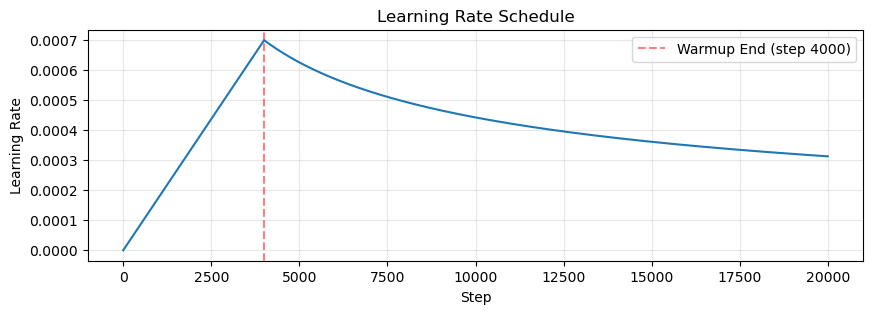

✅ Optimizer + Scheduler 준비 완료


In [93]:
class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    """
    Transformer 논문의 warmup + inverse square root decay 스케줄러.
    """
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)
    
    def get_lr(self):
        step = max(1, self.last_epoch)  # 0 step에서 division by zero 방지
        # 두 식 중 작은 값 사용 → warmup 구간에서는 선형 증가, 이후 root decay
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]


# ─────────── 올바른 순서: Optimizer → Scheduler ───────────
# Optimizer를 먼저 만들고, 그 다음 Scheduler가 optimizer를 받음

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1e-4,                 # 초기값 (scheduler가 매 step 덮어씀)
    betas=(0.9, 0.98),       # 논문 기준 베타
    eps=1e-9
)

scheduler = LearningRateScheduler(optimizer, d_model=D_MODEL, warmup_steps=WARMUP_STEPS)

# 스케줄러가 만들어내는 학습률 곡선 시각화 (확인용)
lrs = []
for i in range(20000):
    scheduler.step()
    lrs.append(scheduler.get_lr()[0])

plt.figure(figsize=(10, 3))
plt.plot(lrs)
plt.axvline(x=WARMUP_STEPS, color='r', linestyle='--', alpha=0.5, 
            label=f'Warmup End (step {WARMUP_STEPS})')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 스케줄러 리셋 (시각화하면서 step이 증가했으므로 다시 초기화)
scheduler = LearningRateScheduler(optimizer, d_model=D_MODEL, warmup_steps=WARMUP_STEPS)
print("✅ Optimizer + Scheduler 준비 완료")

##  Loss 함수

번역은 **각 위치에서 vocab 중 하나를 고르는 분류 문제**.
그래서 **Cross Entropy Loss**를 쓴다.

**핵심 트릭**: 패딩(0) 위치는 loss 계산에서 제외한다.
"패딩을 잘 예측하면 좋다"는 잘못된 학습이될수있다.

In [94]:
loss_object = torch.nn.CrossEntropyLoss(reduction='none')  # 위치별 loss를 따로

def loss_function(real, pred):
    """
    패딩 위치의 loss를 제외하고 평균을 낸다.
    Args:
        real: (batch, seq_len) — 정답 토큰 ID
        pred: (batch, seq_len, vocab_size) — 예측 logits
    """
    # 패딩이 아닌 위치만 마스킹 (real ≠ 0 인 곳을 1로)
    mask = (real != 0).float()
    
    # CrossEntropy는 (N, C, ...) 형태를 기대 → pred를 (batch, vocab, seq_len)로 transpose
    loss_ = loss_object(pred.transpose(1, 2), real)  # (batch, seq_len)
    
    # 패딩 위치는 0으로 만들어서 합산에서 제외
    loss_ = loss_ * mask
    
    # 마스크되지 않은 토큰 개수로 나눠서 평균 — 패딩 비율에 흔들리지 않음
    return loss_.sum() / mask.sum()

print("✅ Loss 함수 정의 완료")

✅ Loss 함수 정의 완료


패딩까지 포함해서 loss를 계산해버리면\
진짜 의미있는 단어들은 학습을 덜할수 있어서 번역성능이 망할수있다..


---

# 학습 (Training)

##  train_step 함수



**Teacher Forcing 기법**:
- 디코더 입력: `<bos> I am a student` (정답을 한 칸 밀어서 입력)
- 정답 (gold): `I am a student <eos>` (실제로 맞춰야 할 다음 토큰들)
- 학습 시에는 매 위치에서 "다음 토큰이 뭐가 나와야 할까?"를 예측하게 함

In [95]:
def train_step(src, tgt, model, optimizer):
    """
    한 배치 학습 스텝.
    Args:
        src: (batch, src_len) — 한국어 입력
        tgt: (batch, tgt_len) — 영어 정답 (앞에 <bos>, 뒤에 <eos> 포함)
    """
    # Teacher Forcing: 디코더 입력은 정답의 마지막 토큰(<eos>) 제외, 정답은 첫 토큰(<bos>) 제외
    # 예: tgt = [<bos>, I, am, a, student, <eos>]
    #     dec_in = [<bos>, I, am, a, student]      ← 디코더에 입력
    #     gold   = [I, am, a, student, <eos>]      ← 맞춰야 할 정답
    dec_in = tgt[:, :-1]
    gold = tgt[:, 1:]
    
    # 마스크 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_in)
    
    # 그래디언트 초기화
    optimizer.zero_grad()
    
    # Forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(
        src, dec_in, enc_mask, dec_mask, dec_enc_mask
    )
    
    # Loss 계산 (패딩 제외)
    loss = loss_function(gold, predictions)
    
    # Backward pass + 가중치 업데이트
    loss.backward()
    optimizer.step()
    scheduler.step()  # 스케줄러도 매 스텝마다 업데이트
    
    return loss.item()

print("✅ train_step 함수 정의 완료")

✅ train_step 함수 정의 완료


##  평가용 번역 함수 (학습 중간 확인용)

매 Epoch마다 예문이 어떻게 번역되는지 보려고 미리보기기능 추가.\
**Greedy Decoding**: 매 스텝에서 가장 확률 높은 토큰을 선택하는 단순한 방법.

In [97]:
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=50):
    """
    한 문장에 대해 번역을 생성한다 (Greedy Decoding).
    """
    model.eval()  # 평가 모드 (dropout 비활성화)
    
    # 입력 전처리
    sentence = preprocess_sentence(sentence)
    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)
    
    # (1, seq_len) 형태로 변환 후 디바이스 이동
    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    # 디코더 시작 토큰 <bos>로 시작
    output = torch.tensor([[tgt_tokenizer.bos_id()]], dtype=torch.long).to(device)
    
    ids = []
    enc_attns_all = dec_attns_all = dec_enc_attns_all = None
    
    with torch.no_grad():  # gradient 계산 비활성화 → 메모리/속도 효율
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)
            
            predictions, enc_attns, dec_attns, dec_enc_attns = model(
                src, output, enc_mask, dec_mask, dec_enc_mask
            )
            
            # 마지막 위치의 예측에서 가장 확률 높은 토큰 선택 (Greedy)
            predicted_id = torch.argmax(predictions[0, -1, :]).item()
            
            # <eos>가 나오면 종료
            if predicted_id == tgt_tokenizer.eos_id():
                enc_attns_all = enc_attns
                dec_attns_all = dec_attns
                dec_enc_attns_all = dec_enc_attns
                break
            
            ids.append(predicted_id)
            
            # 예측 토큰을 디코더 입력에 추가 (다음 스텝에서 사용)
            output = torch.cat([output, torch.tensor([[predicted_id]]).to(device)], dim=-1)
            
            enc_attns_all = enc_attns
            dec_attns_all = dec_attns
            dec_enc_attns_all = dec_enc_attns
    
    result = tgt_tokenizer.decode_ids(ids)
    model.train()  # 다시 학습 모드로
    
    return pieces, result, enc_attns_all, dec_attns_all, dec_enc_attns_all


def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    """번역하고 결과를 출력. plot_attention=True면 Attention Map도 시각화."""
    pieces, result, enc_attns, dec_attns, dec_enc_attns = evaluate(
        sentence, model, src_tokenizer, tgt_tokenizer
    )
    print(f'Input:  {sentence}')
    print(f'Output: {result}')
    
    if plot_attention and enc_attns is not None:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)
    
    return result

print("✅ evaluate, translate 함수 정의 완료")

✅ evaluate, translate 함수 정의 완료


## 학습 루프

Epoch마다:
1. 데이터를 셔플해서 배치 단위로 학습
2. 평균 loss 출력
3. **테스트 예문 4개를 번역**해서 진척도 확인 (루브릭 요구사항)

In [99]:
# 루브릭에 명시된 테스트 예문
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

# 데이터를 디바이스로 이동
enc_train = enc_train.to(device)
dec_train = dec_train.to(device)

# 학습 기록
loss_history = []

print(f"학습 시작 — Epoch {N_EPOCHS}회, Batch Size {BATCH_SIZE}")
print("=" * 70)

for epoch in range(1, N_EPOCHS + 1):
    transformer.train()  # 학습 모드
    
    # 매 Epoch마다 데이터 순서를 섞음 (overfitting 방지)
    perm = torch.randperm(enc_train.size(0))
    enc_shuffled = enc_train[perm]
    dec_shuffled = dec_train[perm]
    
    epoch_losses = []
    n_batches = (enc_shuffled.size(0) + BATCH_SIZE - 1) // BATCH_SIZE
    
    # 배치 단위로 학습
    pbar = tqdm(range(n_batches), desc=f"Epoch {epoch}/{N_EPOCHS}")
    for batch_idx in pbar:
        start = batch_idx * BATCH_SIZE
        end = start + BATCH_SIZE
        
        src_batch = enc_shuffled[start:end]
        tgt_batch = dec_shuffled[start:end]
        
        loss = train_step(src_batch, tgt_batch, transformer, optimizer)
        epoch_losses.append(loss)
        
        # 진행률 바에 현재 loss 표시
        if batch_idx % 50 == 0:
            pbar.set_postfix({'loss': f'{loss:.4f}', 'lr': f'{scheduler.get_lr()[0]:.6f}'})
    
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    
    # ───────── 매 Epoch마다 예문 번역으로 진척도 확인 ─────────
    print(f"\n[Epoch {epoch}] Loss: {avg_loss:.4f}")
    print("─" * 70)
    for i, sent in enumerate(test_sentences, 1):
        result = translate(sent, transformer, ko_tokenizer, en_tokenizer)
        print()
    print("=" * 70 + "\n")

학습 시작 — Epoch 10회, Batch Size 64


Epoch 1/10:   0%|          | 0/1127 [00:00<?, ?it/s]


[Epoch 1] Loss: 6495.9389
──────────────────────────────────────────────────────────────────────
Input:  오바마는 대통령이다.
Output: the cambridge .

Input:  시민들은 도시 속에 산다.
Output: the chuckle .

Input:  커피는 필요 없다.
Output: in the operate .

Input:  일곱 명의 사망자가 발생했다.
Output: a ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever ever




Epoch 2/10:   0%|          | 0/1127 [00:00<?, ?it/s]


[Epoch 2] Loss: 2927.7675
──────────────────────────────────────────────────────────────────────
Input:  오바마는 대통령이다.
Output: in the her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her her

Input:  시민들은 도시 속에 산다.
Output: he said .

Input:  커피는 필요 없다.
Output: i are , in the new i m .

Input:  일곱 명의 사망자가 발생했다.
Output: in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the in the




...


[Epoch 5] Loss: 336.3741
──────────────────────────────────────────────────────────────────────
Input:  오바마는 대통령이다.
Output: the all in the all in the all in the all in the all in the all in the all in the all in the all in the all in the all in the all in the all in the all in the all in the all in the all

Input:  시민들은 도시 속에 산다.
Output: theother woman .

Input:  커피는 필요 없다.
Output: the all in the all in the all all in the all in the all all in that she was but that she was but that she was but but but that had work some agreed .

Input:  일곱 명의 사망자가 발생했다.
Output: the president roh moo hyun in the president roh moo hyun in the president of the gnp up roh moo hyun in the gnp car human rights the gnp car maker .




Epoch 6/10:   0%|          | 0/1127 [00:00<?, ?it/s]


[Epoch 6] Loss: 243.6189
──────────────────────────────────────────────────────────────────────
Input:  오바마는 대통령이다.
Output: the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world

Input:  시민들은 도시 속에 산다.
Output: it some some some some some some some some some some some some some some some in the american out .

Input:  커피는 필요 없다.
Output: the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world american out the world

Input:  일곱 명의 사망자가 발생했다.
Output: the american out the american out the american out the american out the american out the american out the ame

Epoch 7/10:   0%|          | 0/1127 [00:00<?, ?it/s]

KeyboardInterrupt: 

이번생은 망했다.. 처음부터 다시 한다,.. 자세한설명은 위에 너무 열심히 해서 생략함.

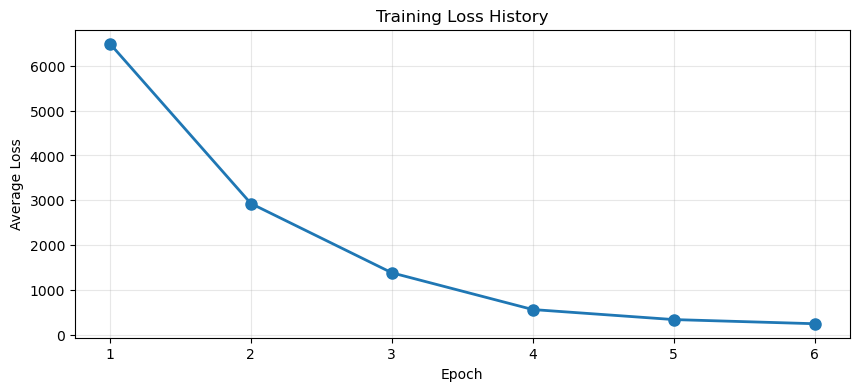

초기 Loss: 6495.9389
최종 Loss: 243.6189
감소량:    6252.3199 (96.2% 감소)


In [100]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, 'o-', linewidth=2, markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss History')
plt.grid(alpha=0.3)
plt.show()

print(f"초기 Loss: {loss_history[0]:.4f}")
print(f"최종 Loss: {loss_history[-1]:.4f}")
print(f"감소량:    {loss_history[0] - loss_history[-1]:.4f} ({(1 - loss_history[-1]/loss_history[0])*100:.1f}% 감소)")